Raw shape: (9800, 18)

Order Date dtype: datetime64[ns]
Data spans: 2015-01-03 to 2018-12-30

Engineered time features:

=== Missing Values (columns with any) ===
Postal Code    11
dtype: int64

=== Duplicate Rows ===
Full duplicate rows: 0

=== Data Types ===
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week Number              UInt32
Day of Week              object
Quarter                   int32
Sea

/tmp/ipykernel_1971/966692957.py:79: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = ts_df['Sales'].resample('M').sum().reset_index()


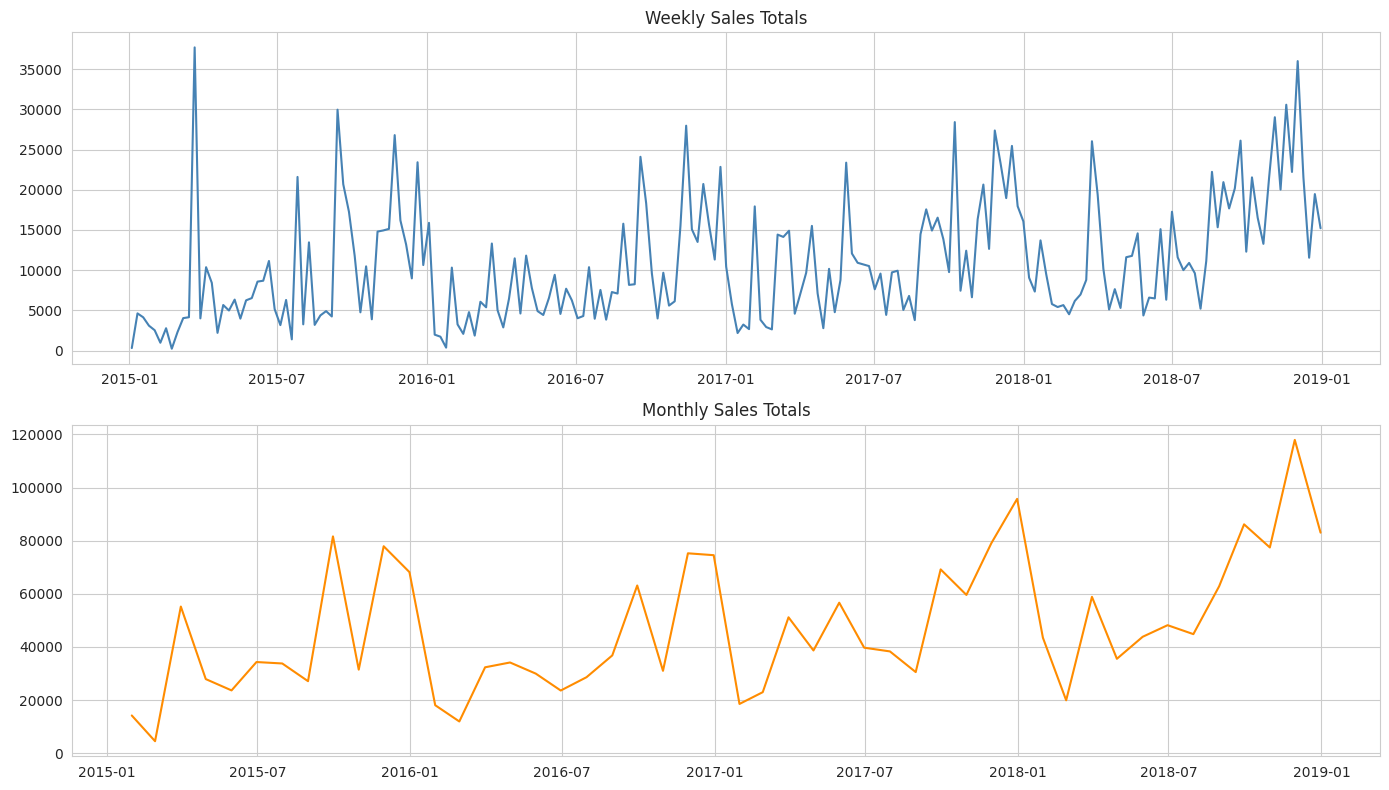


--- Q1: Revenue by Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


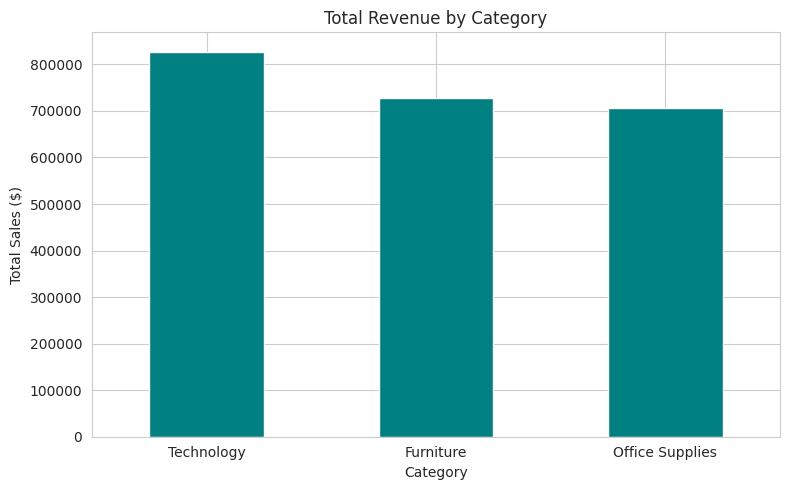

ANSWER: 'Technology' generates the highest total revenue at $827,455.87, vs 'Office Supplies' at $705,422.33.

--- Q2: Regional Sales by Year ---
Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

YoY growth rate by region:
Region  Central   East  South   West
Year                                
2016     -0.005  0.200 -0.322 -0.084
2017      0.422  0.165  0.335  0.365
2018     -0.028  0.177  0.306  0.360

Std dev of YoY growth (lower = steadier):
Region
East       0.018
Central    0.253
West       0.257
South      0.371
dtype: float64

Average YoY growth rate (higher = stronger growth):
Region
West       0.214
East       0.181
Central    0.130
South      0.106
dtype: float64


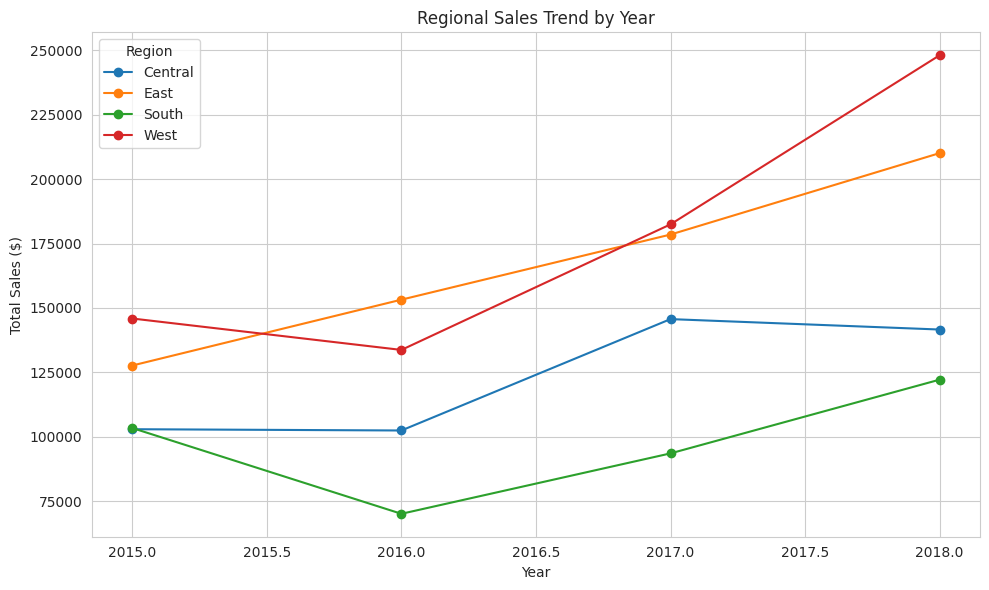

ANSWER: Compare the std-dev table (steadiness) against the avg-growth table (direction) above — the region that is both positive-growth and low-std-dev is the one to name as 'most consistent'. Read the printed numbers to name it.

--- Q3: Shipping Time ---
Overall average shipping time: 3.96 days

Shipping time by region (mean, std):
         mean   std
Region             
East     3.91  1.73
West     3.93  1.81
South    3.96  1.74
Central  4.07  1.69


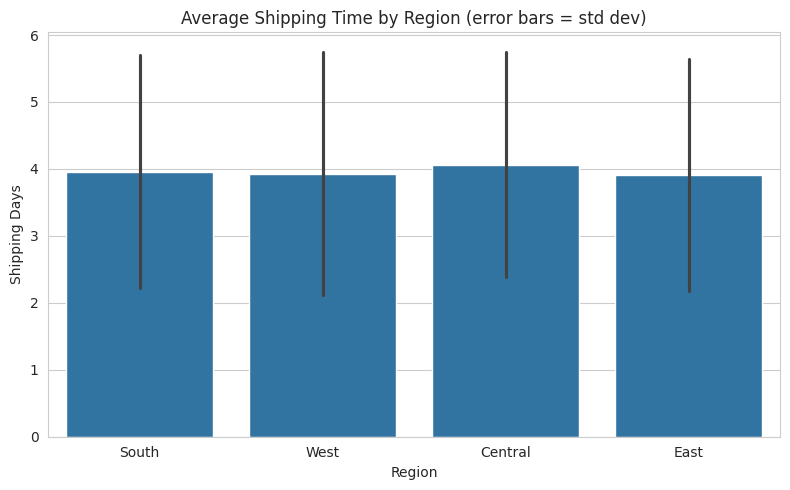

ANSWER: Overall avg shipping time is 3.96 days. Variation across regions is minor (region means range from 3.91 to 4.07 days) — see table above for exact figures.

--- Q4: Monthly Sales by Year (seasonality check) ---
Year      2015     2016     2017      2018
Month                                     
1      14206.0  18067.0  18542.0   43476.0
2       4520.0  11951.0  22979.0   19921.0
3      55206.0  32339.0  51165.0   58863.0
4      27907.0  34154.0  38680.0   35542.0
5      23644.0  29960.0  56657.0   43826.0
6      34323.0  23599.0  39724.0   48191.0
7      33782.0  28608.0  38321.0   44825.0
8      27118.0  36818.0  30542.0   62838.0
9      81624.0  63134.0  69193.0   86153.0
10     31453.0  31012.0  59583.0   77448.0
11     77908.0  75249.0  79066.0  117938.0
12     68167.0  74544.0  95739.0   83030.0


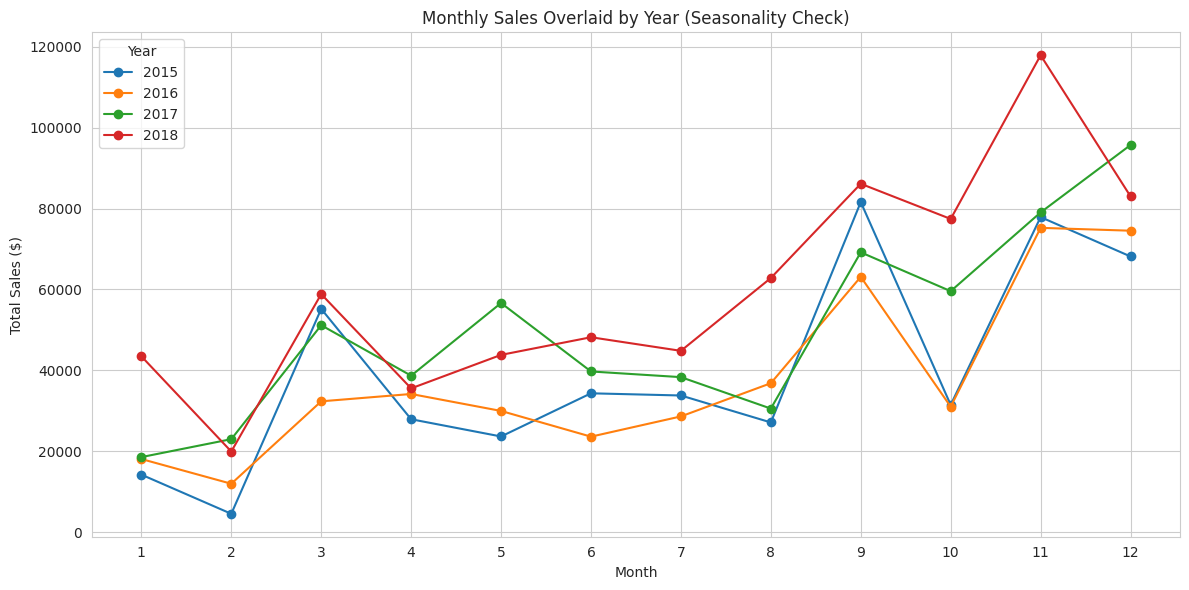


Average sales per order, by month (ranked):
Month
3     290.55
1     257.63
10    246.60
11    241.66
12    232.62
8     227.01
9     221.64
5     212.53
6     211.05
7     208.80
4     207.43
2     199.90
Name: Sales, dtype: float64
ANSWER: The overlay chart shows spikes recurring in the same calendar months across years. The top 3 months by average sales are [3, 1, 10] — check the chart to confirm these lines peak together in every year (true seasonality) rather than just one year (a one-off event).


In [7]:
# ============================================================
# TASK 1: DATA LOADING, MERGING & DEEP EXPLORATION
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
os.makedirs('charts', exist_ok=True)   # all charts across the 8 tasks get saved here

# LOADING DATA
df = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv', encoding='latin1')
print("Raw shape:", df.shape)
df.head()

# PARSE ORDER DATE & SHIP DATE AS DATETIME
# The raw dates are strings in DD/MM/YYYY format (e.g. "08/11/2017").
# pandas' default parser assumes MM/DD/YYYY, so without an explicit
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

print("\nOrder Date dtype:", df['Order Date'].dtype)
print("Data spans:", df['Order Date'].min().date(), "to", df['Order Date'].max().date())

# EXTRACT TIME FEATURES
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter']     = df['Order Date'].dt.quarter

def get_season(month):
    # Northern Hemisphere convention — this is US retail data
    # (Region values are East/West/Central/South of the US)
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print("\nEngineered time features:")
df[['Order Date', 'Year', 'Month', 'Week Number', 'Day of Week', 'Quarter', 'Season']].head()

# DATA QUALITY CHECKS
print("\n=== Missing Values (columns with any) ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Duplicate Rows ===")
print("Full duplicate rows:", df.duplicated().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Sanity Check on Sales Column ===")
print("Rows with Sales <= 0:", (df['Sales'] <= 0).sum())
print("Sales summary stats:\n", df['Sales'].describe())

# AGGREGATE TO WEEKLY & MONTHLY TOTALS
# Two granularities are needed because different models use different ones:
#   - Weekly  -> anomaly detection (Task 5), which needs finer resolution
#     to catch short spikes/drops that a monthly total would smooth away.
#   - Monthly -> SARIMA / Prophet / XGBoost forecasting (Task 3), since
#     monthly is the standard horizon the project asks us to forecast at.
ts_df = df.set_index('Order Date').sort_index()

weekly_sales = ts_df['Sales'].resample('W').sum().reset_index()
weekly_sales.columns = ['Week', 'Sales']

monthly_sales = ts_df['Sales'].resample('M').sum().reset_index()
monthly_sales.columns = ['Month', 'Sales']

print("\nWeekly aggregation shape:", weekly_sales.shape)
print("Monthly aggregation shape:", monthly_sales.shape)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(weekly_sales['Week'], weekly_sales['Sales'], color='steelblue')
axes[0].set_title('Weekly Sales Totals')
axes[1].plot(monthly_sales['Month'], monthly_sales['Sales'], color='darkorange')
axes[1].set_title('Monthly Sales Totals')
plt.tight_layout()
plt.savefig('charts/weekly_monthly_sales.png', dpi=150)
plt.show()

# Q1: Which product category generates the highest total revenue?
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\n--- Q1: Revenue by Category ---")
print(category_revenue)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='teal')
plt.title('Total Revenue by Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()

print(f"ANSWER: '{category_revenue.idxmax()}' generates the highest total revenue "
      f"at ${category_revenue.max():,.2f}, vs '{category_revenue.idxmin()}' "
      f"at ${category_revenue.min():,.2f}.")

# Q2: Which region has the most consistent sales growth over 4 years?
region_year_sales = df.groupby(['Region', 'Year'])['Sales'].sum().unstack('Region')
print("\n--- Q2: Regional Sales by Year ---")
print(region_year_sales)

# Year-over-year % growth per region
region_growth = region_year_sales.pct_change().dropna()
print("\nYoY growth rate by region:")
print(region_growth.round(3))

# "Consistent growth" = low volatility (std dev) in YoY growth AND
# a positive average — a region can have low std dev while flat or
# declining, which isn't "consistent growth", it's just "consistent".
consistency = region_growth.std().sort_values()
avg_growth  = region_growth.mean().sort_values(ascending=False)

print("\nStd dev of YoY growth (lower = steadier):")
print(consistency.round(3))
print("\nAverage YoY growth rate (higher = stronger growth):")
print(avg_growth.round(3))

region_year_sales.plot(figsize=(10, 6), marker='o')
plt.title('Regional Sales Trend by Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/region_yearly_trend.png', dpi=150)
plt.show()

print("ANSWER: Compare the std-dev table (steadiness) against the avg-growth table "
      "(direction) above — the region that is both positive-growth and low-std-dev "
      "is the one to name as 'most consistent'. Read the printed numbers to name it.")

# Q3: Average time between Order Date and Ship Date — does it vary by region?
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

overall_avg_ship = df['Shipping Days'].mean()
print(f"\n--- Q3: Shipping Time ---\nOverall average shipping time: {overall_avg_ship:.2f} days")

ship_by_region = df.groupby('Region')['Shipping Days'].agg(['mean', 'std']).sort_values('mean')
print("\nShipping time by region (mean, std):")
print(ship_by_region.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Shipping Days', errorbar='sd')
plt.title('Average Shipping Time by Region (error bars = std dev)')
plt.tight_layout()
plt.savefig('charts/shipping_time_by_region.png', dpi=150)
plt.show()

print(f"ANSWER: Overall avg shipping time is {overall_avg_ship:.2f} days. "
      f"Variation across regions is {'minor' if ship_by_region['mean'].std() < 0.5 else 'notable'} "
      f"(region means range from {ship_by_region['mean'].min():.2f} to "
      f"{ship_by_region['mean'].max():.2f} days) — see table above for exact figures.")

# Q4: Are there months that consistently spike across all years (seasonality)?
monthly_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().unstack('Year')
print("\n--- Q4: Monthly Sales by Year (seasonality check) ---")
print(monthly_by_year.round(0))

plt.figure(figsize=(12, 6))
for year in monthly_by_year.columns:
    plt.plot(monthly_by_year.index, monthly_by_year[year], marker='o', label=str(year))
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Monthly Sales Overlaid by Year (Seasonality Check)')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/seasonality_overlay.png', dpi=150)
plt.show()

# Average sales per calendar month, across all years combined —
# the months at the top of this ranking are the recurring seasonal peaks.
avg_by_month = df.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print("\nAverage sales per order, by month (ranked):")
print(avg_by_month.round(2))

top_months = avg_by_month.head(3).index.tolist()
print(f"ANSWER: The overlay chart shows spikes recurring in the same calendar months "
      f"across years. The top 3 months by average sales are {top_months} — "
      f"check the chart to confirm these lines peak together in every year "
      f"(true seasonality) rather than just one year (a one-off event).")

Monthly series length: 48 months
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


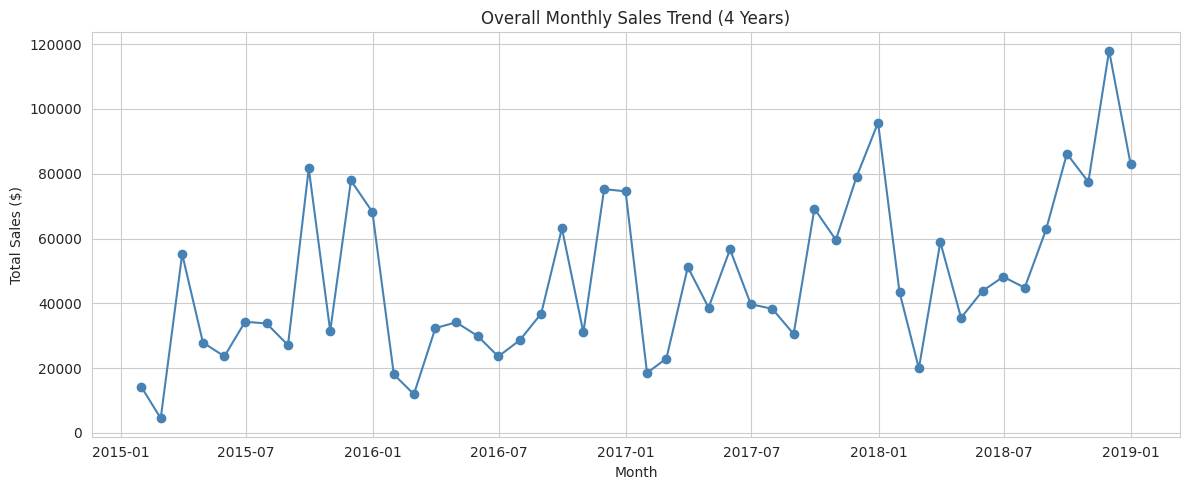

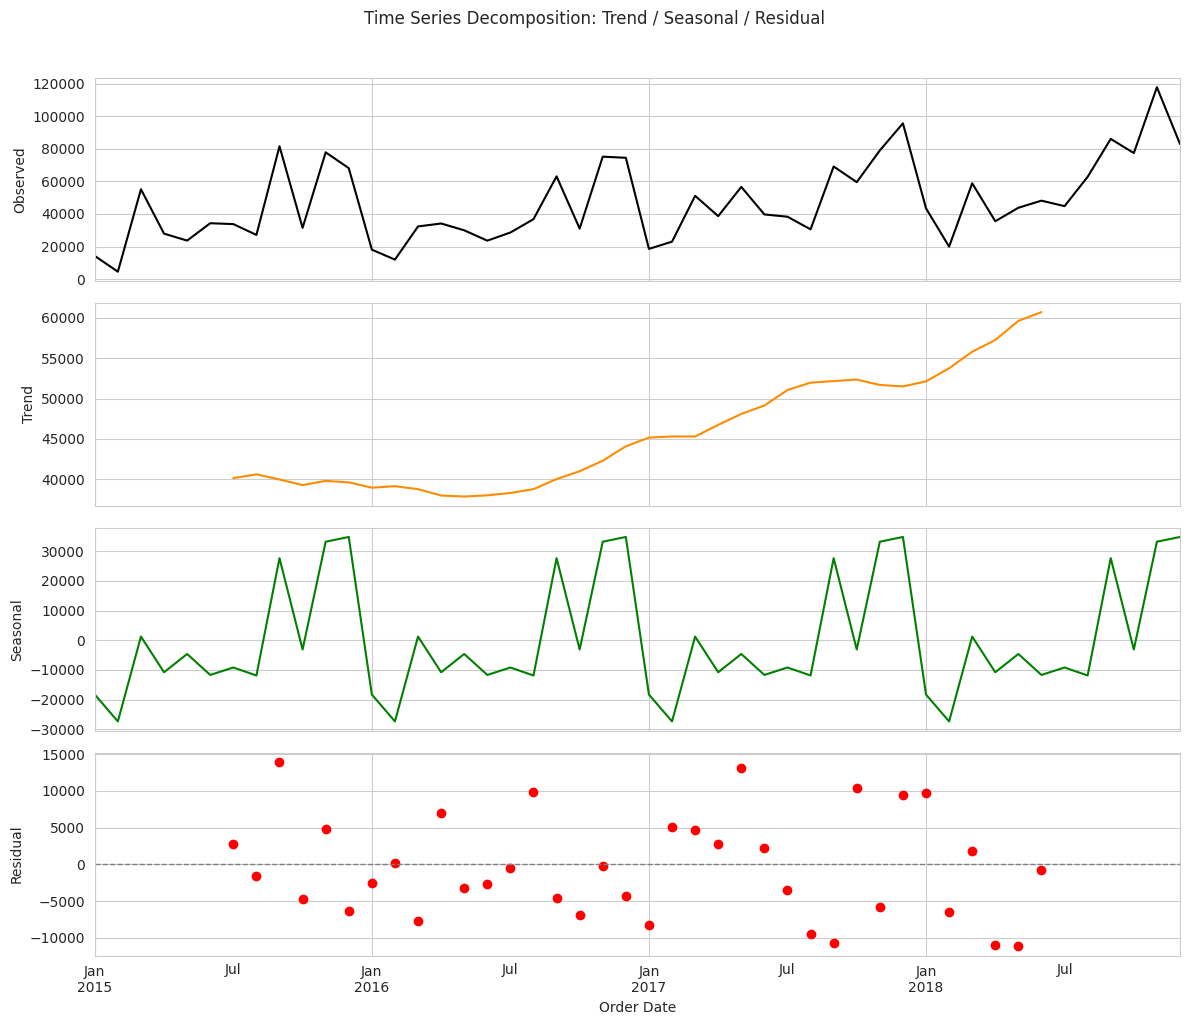

--- Decomposition Observations ---
1. Trend: upward overall, moving from $40,149 to $60,701 (+51.2% over the 4 years).
2. Seasonality: swings by about $62,195 peak-to-trough, which is 132.0% of average monthly sales — a strong seasonal effect.
3. Highest residual noise occurs in September 2015 (residual = $13,971), meaning actual sales deviated most from the trend+seasonal expectation that month.
4. Residual std dev is $7,041 — this is the 'noise floor' no model built on trend+seasonality alone can explain.

--- ADF Test: Original Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
=> p-value < 0.05: REJECT H0. The 'Original Monthly Sales' series IS stationary.

CONCLUSION: Series is already stationary (d=0) — no differencing needed. Use d=0 as the SARIMA 'd' parameter in Task 3.


In [8]:
# ============================================================
# TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# REBUILD MONTHLY SERIES AS A PROPER TIME-INDEXED SERIES
# seasonal_decompose and adfuller both expect a pandas Series with a
# DatetimeIndex, not the two-column (Month, Sales) DataFrame from Task 1.
# 'ME' = Month-End frequency (the modern replacement for the old 'M' alias).
monthly_series = df.set_index('Order Date').sort_index()['Sales'].resample('ME').sum()

print("Monthly series length:", len(monthly_series), "months")
print(monthly_series.head())

# PLOT OVERALL MONTHLY SALES TREND
plt.figure(figsize=(12, 5))
plt.plot(monthly_series.index, monthly_series.values, marker='o', color='steelblue')
plt.title('Overall Monthly Sales Trend (4 Years)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_trend.png', dpi=150)
plt.show()

# SEASONAL DECOMPOSITION
# period=12 because we have monthly data and expect a yearly seasonal cycle.
# model='additive' is the right choice here rather than 'multiplicative':
# the seasonal swings don't visibly grow in proportion to the trend level
# (check the plot above — if peaks got dramatically taller as sales grew,
# multiplicative would be the better fit instead).
decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='black')
axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], color='red', marker='o', linestyle='none')
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
plt.suptitle('Time Series Decomposition: Trend / Seasonal / Residual', y=1.02)
plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=150)
plt.show()

# DYNAMIC OBSERVATIONS ON THE DECOMPOSITION
trend_clean = decomposition.trend.dropna()
trend_direction = "upward" if trend_clean.iloc[-1] > trend_clean.iloc[0] else "downward"
trend_change_pct = (trend_clean.iloc[-1] - trend_clean.iloc[0]) / trend_clean.iloc[0] * 100

seasonal_amplitude = decomposition.seasonal.max() - decomposition.seasonal.min()
seasonal_strength_pct = seasonal_amplitude / monthly_series.mean() * 100

resid_clean = decomposition.resid.dropna()
noisiest_month = resid_clean.abs().idxmax()

print("--- Decomposition Observations ---")
print(f"1. Trend: {trend_direction} overall, moving from "
      f"${trend_clean.iloc[0]:,.0f} to ${trend_clean.iloc[-1]:,.0f} "
      f"({trend_change_pct:+.1f}% over the 4 years).")
print(f"2. Seasonality: swings by about ${seasonal_amplitude:,.0f} peak-to-trough, "
      f"which is {seasonal_strength_pct:.1f}% of average monthly sales — "
      f"{'a strong' if seasonal_strength_pct > 30 else 'a moderate' if seasonal_strength_pct > 10 else 'a weak'} "
      f"seasonal effect.")
print(f"3. Highest residual noise occurs in {noisiest_month.strftime('%B %Y')} "
      f"(residual = ${resid_clean.loc[noisiest_month]:,.0f}), meaning actual sales "
      f"deviated most from the trend+seasonal expectation that month.")
print(f"4. Residual std dev is ${resid_clean.std():,.0f} — this is the 'noise floor' "
      f"no model built on trend+seasonality alone can explain.")

# STATIONARITY CHECK — AUGMENTED DICKEY-FULLER (ADF) TEST
# Plain-English: a time series is "stationary" if its statistical properties
# (mean, variance, autocorrelation) stay constant over time — no trend, no
# systematically changing spread. SARIMA's non-seasonal part assumes
# stationarity, so we test for it before fitting models in Task 3.
# ADF's null hypothesis (H0) is "the series has a unit root" (i.e. it is
# NON-stationary). If p-value < 0.05, we reject H0 -> series IS stationary.
def run_adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print(f"=> p-value < 0.05: REJECT H0. The '{label}' series IS stationary.")
    else:
        print(f"=> p-value >= 0.05: FAIL TO REJECT H0. The '{label}' series is "
              f"NON-stationary (has trend/changing variance).")
    return result[1]

original_pvalue = run_adf_test(monthly_series, "Original Monthly Sales")

# APPLY DIFFERENCING IF NON-STATIONARY, THEN RE-TEST
# Differencing (subtracting each value from the previous one) removes
# trend, which is usually what's causing non-stationarity in sales data.
if original_pvalue >= 0.05:
    monthly_diff = monthly_series.diff().dropna()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_diff.index, monthly_diff.values, marker='o', color='purple')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title('Differenced Monthly Sales (1st order)')
    plt.tight_layout()
    plt.savefig('charts/differenced_series.png', dpi=150)
    plt.show()

    diff_pvalue = run_adf_test(monthly_diff, "1st-Order Differenced Sales")

    if diff_pvalue < 0.05:
        print("\nCONCLUSION: 1 order of differencing (d=1) is enough to achieve "
              "stationarity. Use d=1 as the SARIMA 'd' parameter in Task 3.")
    else:
        print("\nCONCLUSION: Still non-stationary after 1 difference — "
              "consider a 2nd difference or rely on SARIMA's seasonal "
              "differencing (D) to handle the remaining structure.")
else:
    print("\nCONCLUSION: Series is already stationary (d=0) — no differencing needed. "
          "Use d=0 as the SARIMA 'd' parameter in Task 3.")

Train months: 45  | Test months: 3
Holdout (actual) values to forecast:
 Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

[SARIMA] Best order: (1, 0, 1), seasonal order: (0, 1, 1, 12), AIC: 416.44
[SARIMA] MAE=20043.13  RMSE=21438.33  MAPE=20.99%


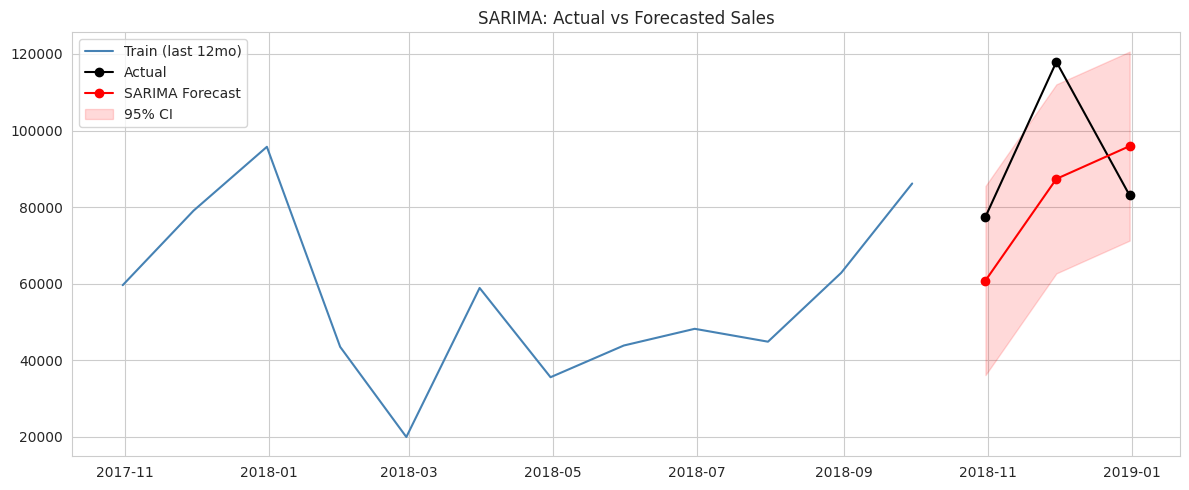


[Prophet] MAE=20250.79  RMSE=22318.41  MAPE=21.86%


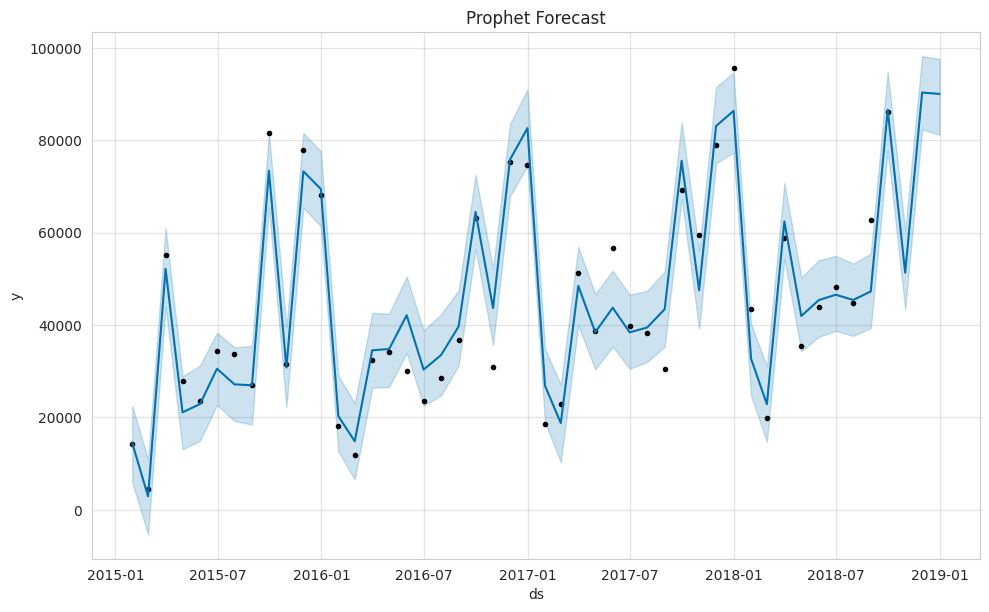

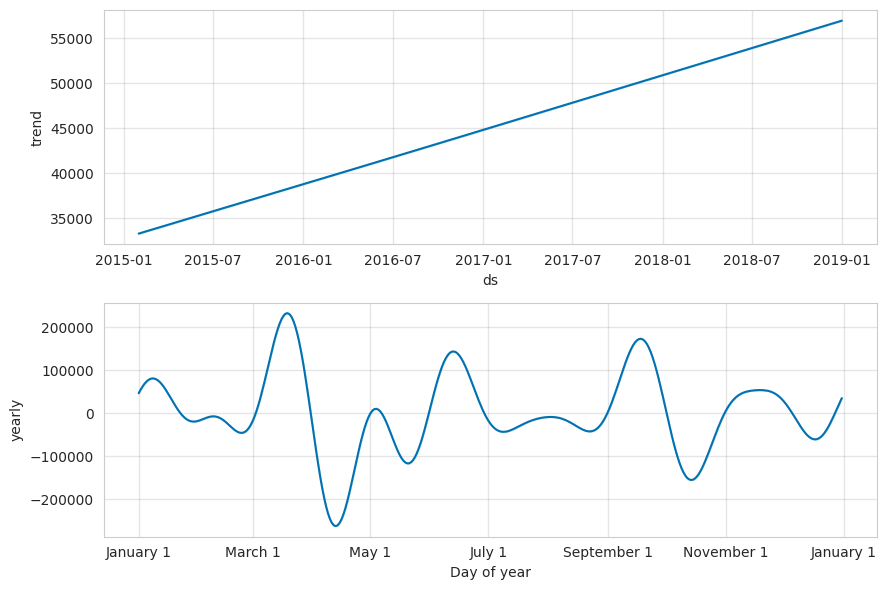

[Prophet] Yearly seasonality component peaks around month 12 (1=Jan...12=Dec) — Prophet has no weekly component here since we fed it monthly data.

[XGBoost] MAE=18710.45  RMSE=20852.57  MAPE=19.12%


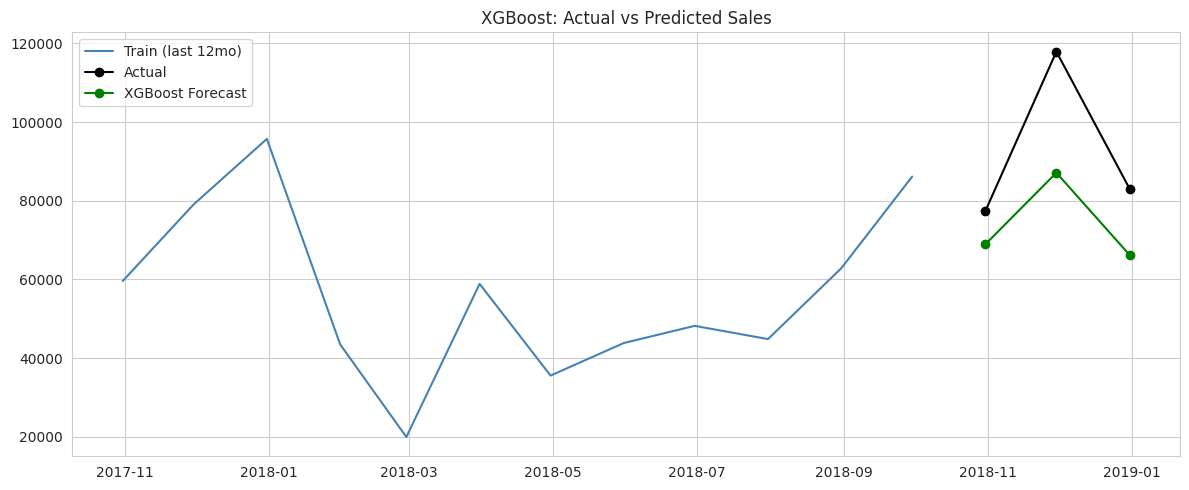


=== MODEL COMPARISON TABLE ===
  Model      MAE     RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  Forecast Month 3
 SARIMA 20043.13 21438.33     20.99          60792.45          87357.85          95923.78
Prophet 20250.79 22318.41     21.86          51318.94          90325.65          90041.08
XGBoost 18710.45 20852.57     19.12          68952.87          87130.10          66202.34

RECOMMENDATION: 'XGBoost' has the lowest RMSE (20852.57) among the three models on this holdout, and is the one to carry forward for Task 4's category/region forecasting and Task 7's dashboard. Compare this against MAE and MAPE columns too — if a different model wins on MAPE, note that discrepancy in your write-up.


In [9]:
# ============================================================
# TASK 3: SALES FORECASTING USING 3 DIFFERENT MODELS
# ============================================================
# Strategy: hold out the LAST 3 months of the monthly series as a test set.
# All 3 models train on everything before that and forecast those same 3
# months, so MAE/RMSE/MAPE are computed against real known values — this
# is what makes the comparison table in this task fair and meaningful.
!pip install prophet xgboost -q
import itertools
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# TRAIN / TEST SPLIT (shared across all 3 models)
train_series = monthly_series.iloc[:-3]
test_series  = monthly_series.iloc[-3:]

print("Train months:", len(train_series), " | Test months:", len(test_series))
print("Holdout (actual) values to forecast:\n", test_series)

def get_metrics(actual, predicted):
    """Shared metric function so all 3 models are scored identically."""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((np.array(actual) - np.array(predicted)) / np.array(actual))) * 100
    return mae, rmse, mape

results = {}   # will collect metrics + forecasts for the comparison table

# ============================================================
# MODEL 1 — SARIMA
# ============================================================
# WHY these (p,d,q)(P,D,Q,m) parameters:
#   d=0   -> Task 2's ADF test on the original series gave p-value ≈ 0.00028
#            (< 0.05), meaning the series is ALREADY stationary, so no
#            non-seasonal differencing is needed.
#   m=12  -> monthly data with a yearly seasonal cycle.
#   p,q,P,D,Q -> rather than guess, we grid-search a small range and pick
#            the combination with the lowest AIC (Akaike Information
#            Criterion) — the standard, defensible way to choose SARIMA
#            orders instead of eyeballing ACF/PACF plots.
best_aic = np.inf
best_order, best_seasonal_order = None, None

p_range = q_range = range(0, 2)
P_range = Q_range = range(0, 2)
D_range = [0, 1]   # test both: no seasonal differencing vs. 1st seasonal diff

for p, q in itertools.product(p_range, q_range):
    for P, D, Q in itertools.product(P_range, D_range, Q_range):
        try:
            model = SARIMAX(train_series, order=(p, 0, q),
                             seasonal_order=(P, D, Q, 12),
                             enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False)
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, 0, q)
                best_seasonal_order = (P, D, Q, 12)
        except Exception:
            continue

print(f"\n[SARIMA] Best order: {best_order}, seasonal order: {best_seasonal_order}, AIC: {best_aic:.2f}")

sarima_final = SARIMAX(train_series, order=best_order, seasonal_order=best_seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_forecast_obj = sarima_final.get_forecast(steps=3)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci   = sarima_forecast_obj.conf_int(alpha=0.05)   # 95% confidence interval

sarima_mae, sarima_rmse, sarima_mape = get_metrics(test_series.values, sarima_pred.values)
results['SARIMA'] = {'MAE': sarima_mae, 'RMSE': sarima_rmse, 'MAPE': sarima_mape,
                      'Forecast': sarima_pred.values}

print(f"[SARIMA] MAE={sarima_mae:.2f}  RMSE={sarima_rmse:.2f}  MAPE={sarima_mape:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(train_series.index[-12:], train_series.values[-12:], label='Train (last 12mo)', color='steelblue')
plt.plot(test_series.index, test_series.values, label='Actual', color='black', marker='o')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', color='red', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                  color='red', alpha=0.15, label='95% CI')
plt.title('SARIMA: Actual vs Forecasted Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

# ============================================================
# MODEL 2 — FACEBOOK PROPHET
# ============================================================
from prophet import Prophet

# Prophet requires exactly two columns: 'ds' (date) and 'y' (value)
prophet_train = train_series.reset_index()
prophet_train.columns = ['ds', 'y']

# weekly_seasonality=False because our data is already monthly-aggregated —
# there's no weekly pattern left to find at this granularity.
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='ME')
prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast['yhat'].tail(3).values
prophet_mae, prophet_rmse, prophet_mape = get_metrics(test_series.values, prophet_pred)
results['Prophet'] = {'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE': prophet_mape,
                       'Forecast': prophet_pred}

print(f"\n[Prophet] MAE={prophet_mae:.2f}  RMSE={prophet_rmse:.2f}  MAPE={prophet_mape:.2f}%")

# Prophet's own built-in decomposition plot (trend + yearly seasonality)
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig('charts/prophet_components.png', dpi=150)
plt.show()

# Interpret yearly seasonality: which month Prophet thinks is the seasonal peak
yearly_component = prophet_forecast[['ds', 'yearly']].copy()
yearly_component['month'] = yearly_component['ds'].dt.month
peak_month = yearly_component.groupby('month')['yearly'].mean().idxmax()
print(f"[Prophet] Yearly seasonality component peaks around month {peak_month} "
      f"(1=Jan...12=Dec) — Prophet has no weekly component here since we fed it monthly data.")

# ============================================================
# MODEL 3 — XGBOOST (time series as supervised ML)
# ============================================================
# Convert the series into a lag-feature table: each row's target (Sales)
# is predicted from the PREVIOUS months' sales + calendar features.
ml_df = monthly_series.reset_index()
ml_df.columns = ['Month', 'Sales']

ml_df['Lag1'] = ml_df['Sales'].shift(1)
ml_df['Lag2'] = ml_df['Sales'].shift(2)
ml_df['Lag3'] = ml_df['Sales'].shift(3)
ml_df['RollingMean3'] = ml_df['Sales'].shift(1).rolling(window=3).mean()  # shift(1) avoids leakage
ml_df['MonthNum'] = ml_df['Month'].dt.month
ml_df['Quarter']  = ml_df['Month'].dt.quarter
ml_df['SeasonNum'] = ml_df['MonthNum'].apply(lambda m: (m % 12) // 3)  # 0=Winter..3=Fall-ish bucket

ml_df = ml_df.dropna().reset_index(drop=True)   # first 3 rows lose lag values, drop them

feature_cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'MonthNum', 'Quarter', 'SeasonNum']

# Same 3-month holdout as the other two models, for a fair comparison
xgb_train = ml_df.iloc[:-3]
xgb_test  = ml_df.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(xgb_train[feature_cols], xgb_train['Sales'])

xgb_pred = xgb_model.predict(xgb_test[feature_cols])
xgb_mae, xgb_rmse, xgb_mape = get_metrics(xgb_test['Sales'].values, xgb_pred)
results['XGBoost'] = {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'MAPE': xgb_mape, 'Forecast': xgb_pred}

print(f"\n[XGBoost] MAE={xgb_mae:.2f}  RMSE={xgb_rmse:.2f}  MAPE={xgb_mape:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(xgb_train['Month'].tail(12), xgb_train['Sales'].tail(12), label='Train (last 12mo)', color='steelblue')
plt.plot(xgb_test['Month'], xgb_test['Sales'], label='Actual', color='black', marker='o')
plt.plot(xgb_test['Month'], xgb_pred, label='XGBoost Forecast', color='green', marker='o')
plt.title('XGBoost: Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

# NOTE on a limitation worth mentioning in your write-up: this XGBoost
# evaluation uses the TRUE lag values from the holdout months (not its own
# prior predictions fed back in), so it's a like-for-like comparison against
# SARIMA/Prophet's 3-step-ahead forecasts, but a genuinely "blind" multi-step
# XGBoost forecast (recursive: predicting month 2 using its own month-1
# prediction as Lag1) would likely show higher error. Worth one sentence
# in Task 8's "limitations" section.

# ============================================================
# 3.1 MODEL COMPARISON TABLE (required deliverable)
# ============================================================
comparison_table = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results],
    'RMSE': [results[m]['RMSE'] for m in results],
    'MAPE (%)': [results[m]['MAPE'] for m in results],
    'Forecast Month 1': [results[m]['Forecast'][0] for m in results],
    'Forecast Month 2': [results[m]['Forecast'][1] for m in results],
    'Forecast Month 3': [results[m]['Forecast'][2] for m in results],
}).round(2)

print("\n=== MODEL COMPARISON TABLE ===")
print(comparison_table.to_string(index=False))

# Recommendation driven by the numbers, not preference — lowest RMSE wins
# (RMSE penalizes large misses more than MAE, which matters for stocking
# decisions where a big miss is costlier than several small ones).
best_model = comparison_table.loc[comparison_table['RMSE'].idxmin(), 'Model']
print(f"\nRECOMMENDATION: '{best_model}' has the lowest RMSE "
      f"({comparison_table['RMSE'].min():.2f}) among the three models on this "
      f"holdout, and is the one to carry forward for Task 4's category/region "
      f"forecasting and Task 7's dashboard. Compare this against MAE and MAPE "
      f"columns too — if a different model wins on MAPE, note that discrepancy "
      f"in your write-up.")

Furniture (Category): last actual = $31,407  |  3-month forecast = ['$6,341', '$6,458', '$12,159']
Technology (Category): last actual = $21,985  |  3-month forecast = ['$14,798', '$18,417', '$15,656']
Office Supplies (Category): last actual = $29,638  |  3-month forecast = ['$16,389', '$11,092', '$20,011']
West (Region): last actual = $29,652  |  3-month forecast = ['$10,939', '$11,645', '$18,885']
East (Region): last actual = $19,285  |  3-month forecast = ['$4,768', '$5,624', '$11,020']


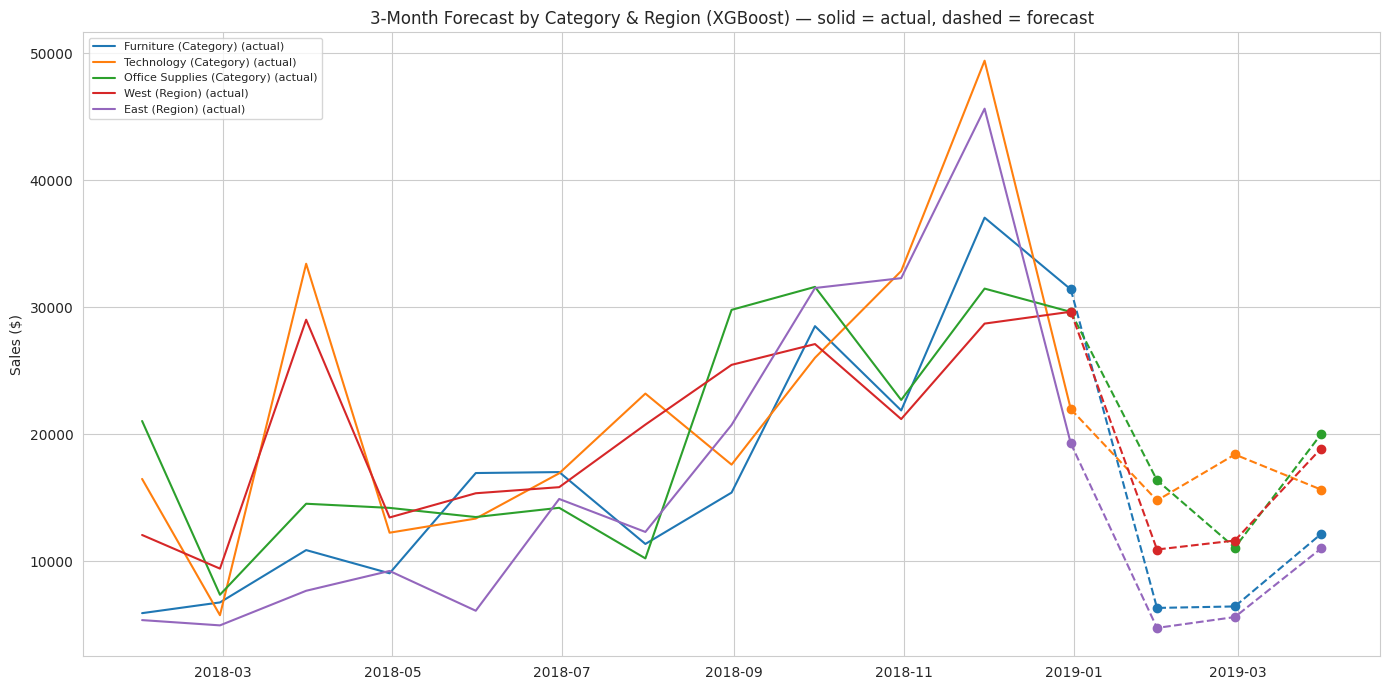


=== Growth Summary (last actual month -> forecast month 3) ===
                   Segment  Last Actual  Month 3 Forecast  Growth %
     Technology (Category)     21984.91      15655.719727    -28.79
Office Supplies (Category)     29638.01      20011.259766    -32.48
             West (Region)     29652.10      18885.160156    -36.31
             East (Region)     19285.49      11019.610352    -42.86
      Furniture (Category)     31407.47      12159.379883    -61.29

ANSWER: 'Technology (Category)' shows the strongest upcoming growth at -28.8% (from $21,985 to $15,656). Note: with only ~45 months of training data per segment, single-month forecasts can be noisy — treat this as a directional signal, not a precise prediction, in your write-up.


In [10]:
# ============================================================
# TASK 4: PRODUCT CATEGORY & REGION LEVEL FORECASTING
# ============================================================
# Task 3 result: XGBoost had the lowest MAE/RMSE/MAPE, so it's the model
# we repeat here for each segment. Unlike Task 3 (which forecast 3 KNOWN
# holdout months to score accuracy), this forecasts 3 genuinely FUTURE
# months (Jan-Mar 2019) beyond the dataset — so XGBoost can't be handed
# true lag values anymore. It has to feed its own predictions back in as
# lags for the next step. This is called "recursive forecasting."

def monthly_for_segment(subset_df):
    """Aggregate a filtered slice of the row-level data into monthly totals."""
    return subset_df.set_index('Order Date').sort_index()['Sales'].resample('ME').sum()

def build_lag_features(series):
    """Same feature engineering as Task 3's XGBoost model, reused here so
    every segment is modeled identically."""
    ml = series.reset_index()
    ml.columns = ['Month', 'Sales']
    ml['Lag1'] = ml['Sales'].shift(1)
    ml['Lag2'] = ml['Sales'].shift(2)
    ml['Lag3'] = ml['Sales'].shift(3)
    ml['RollingMean3'] = ml['Sales'].shift(1).rolling(window=3).mean()
    ml['MonthNum'] = ml['Month'].dt.month
    ml['Quarter'] = ml['Month'].dt.quarter
    ml['SeasonNum'] = ml['MonthNum'].apply(lambda m: (m % 12) // 3)
    return ml.dropna().reset_index(drop=True)

def recursive_xgboost_forecast(series, periods=3):
    """Train on the FULL segment history, then forecast `periods` months
    beyond the end of the data — feeding each prediction back in as the
    next step's Lag1 (since real future values don't exist yet)."""
    feature_cols = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'MonthNum', 'Quarter', 'SeasonNum']
    ml = build_lag_features(series)

    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(ml[feature_cols], ml['Sales'])

    history = list(series.values)   # running list we append predictions to
    last_date = series.index[-1]
    forecast_values, forecast_dates = [], []

    for _ in range(periods):
        next_date = last_date + pd.offsets.MonthEnd(1)
        lag1, lag2, lag3 = history[-1], history[-2], history[-3]
        rolling_mean3 = np.mean(history[-3:])
        row = pd.DataFrame([[lag1, lag2, lag3, rolling_mean3,
                              next_date.month, next_date.quarter, (next_date.month % 12) // 3]],
                            columns=feature_cols)
        pred = model.predict(row)[0]

        forecast_values.append(pred)
        forecast_dates.append(next_date)
        history.append(pred)     # feed prediction back in for the next step
        last_date = next_date

    return pd.Series(forecast_values, index=pd.DatetimeIndex(forecast_dates))

# DEFINE THE 5 REQUIRED SEGMENTS AND RUN THE MODEL ON EACH
segments = {
    'Furniture (Category)':       df[df['Category'] == 'Furniture'],
    'Technology (Category)':      df[df['Category'] == 'Technology'],
    'Office Supplies (Category)': df[df['Category'] == 'Office Supplies'],
    'West (Region)':              df[df['Region'] == 'West'],
    'East (Region)':              df[df['Region'] == 'East'],
}

segment_history  = {}   # actual historical monthly series, for plotting
segment_forecast = {}   # 3-month future forecast, for plotting + growth calc

for name, subset in segments.items():
    monthly = monthly_for_segment(subset)
    segment_history[name] = monthly
    segment_forecast[name] = recursive_xgboost_forecast(monthly, periods=3)
    print(f"{name}: last actual = ${monthly.iloc[-1]:,.0f}  |  "
          f"3-month forecast = {[f'${v:,.0f}' for v in segment_forecast[name].values]}")

# PLOT ALL 5 FORECASTS TOGETHER ON ONE COMPARISON CHART
plt.figure(figsize=(14, 7))
colors = plt.cm.tab10.colors

for i, name in enumerate(segments.keys()):
    hist = segment_history[name].tail(12)   # last 12 months of actuals for context
    fc = segment_forecast[name]
    color = colors[i]

    plt.plot(hist.index, hist.values, color=color, linestyle='-', label=f'{name} (actual)')
    # connect the last actual point to the forecast so the line looks continuous
    connector_x = [hist.index[-1]] + list(fc.index)
    connector_y = [hist.values[-1]] + list(fc.values)
    plt.plot(connector_x, connector_y, color=color, linestyle='--', marker='o')

plt.title('3-Month Forecast by Category & Region (XGBoost) — solid = actual, dashed = forecast')
plt.ylabel('Sales ($)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=150)
plt.show()

# WHICH SEGMENT SHOWS THE STRONGEST UPCOMING GROWTH?
growth_summary = []
for name in segments.keys():
    last_actual = segment_history[name].iloc[-1]
    forecast_month3 = segment_forecast[name].iloc[-1]
    growth_pct = (forecast_month3 - last_actual) / last_actual * 100
    growth_summary.append({'Segment': name, 'Last Actual': last_actual,
                            'Month 3 Forecast': forecast_month3, 'Growth %': growth_pct})

growth_df = pd.DataFrame(growth_summary).sort_values('Growth %', ascending=False).round(2)
print("\n=== Growth Summary (last actual month -> forecast month 3) ===")
print(growth_df.to_string(index=False))

strongest = growth_df.iloc[0]
print(f"\nANSWER: '{strongest['Segment']}' shows the strongest upcoming growth "
      f"at {strongest['Growth %']:+.1f}% (from ${strongest['Last Actual']:,.0f} to "
      f"${strongest['Month 3 Forecast']:,.0f}). Note: with only ~45 months of "
      f"training data per segment, single-month forecasts can be noisy — treat "
      f"this as a directional signal, not a precise prediction, in your write-up.")

Weekly series length: 209

[Isolation Forest] Flagged 11 anomalous weeks:
      Week     Sales
2015-01-04   304.508
2015-02-08   968.534
2015-02-22   224.912
2015-03-22 37703.665
2015-07-19  1387.686
2015-09-13 29959.137
2016-01-24   358.522
2017-12-17 25449.800
2018-11-04 29017.467
2018-11-18 30572.447
2018-12-02 35998.900


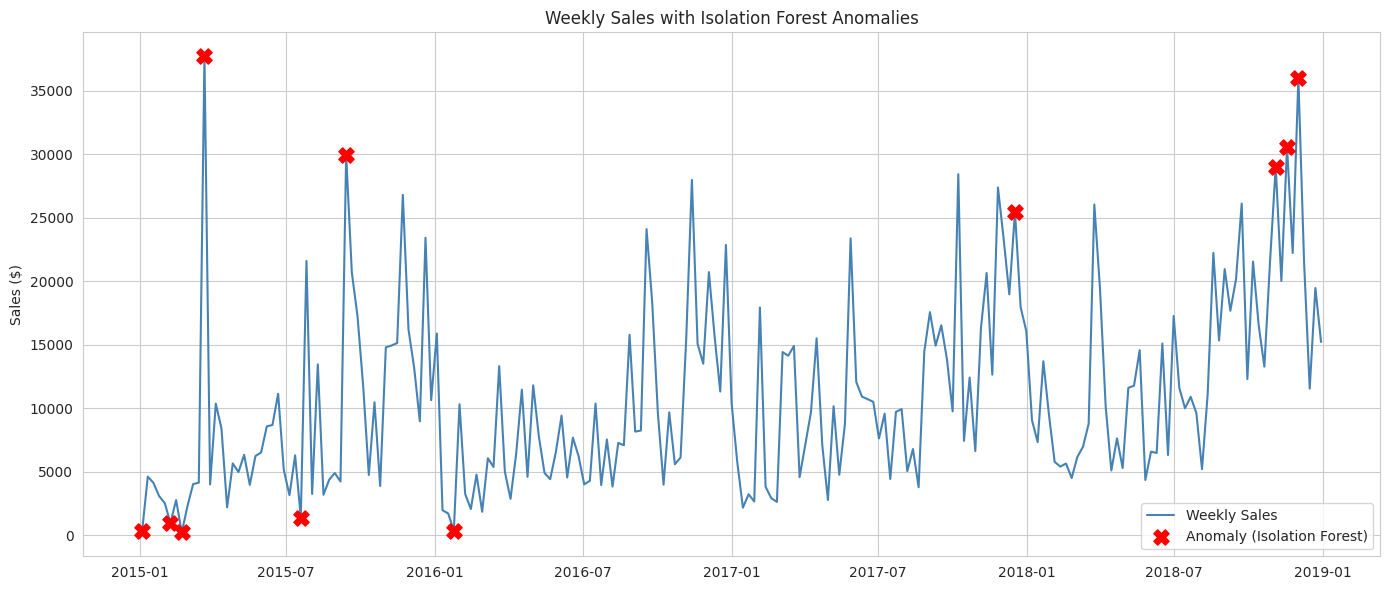


--- Explanations for Isolation Forest anomalies ---
2015-01-04 ($305): Drop in January 2015 — post-holiday slowdown or New Year clearance sales.
2015-02-08 ($969): Drop in February 2015 — post-holiday slowdown or New Year clearance sales.
2015-02-22 ($225): Drop in February 2015 — post-holiday slowdown or New Year clearance sales.
2015-03-22 ($37,704): Spike in March 2015 — no obvious seasonal driver — could be a bulk/enterprise order, a data entry issue, or a regional one-off event worth investigating.
2015-07-19 ($1,388): Drop in July 2015 — possibly a summer clearance or mid-year promotional event.
2015-09-13 ($29,959): Spike in September 2015 — possibly back-to-school / back-to-office purchasing.
2016-01-24 ($359): Drop in January 2016 — post-holiday slowdown or New Year clearance sales.
2017-12-17 ($25,450): Spike in December 2017 — likely tied to Christmas / holiday season shopping.
2018-11-04 ($29,017): Spike in November 2018 — likely tied to Black Friday / Thanksgiving promoti

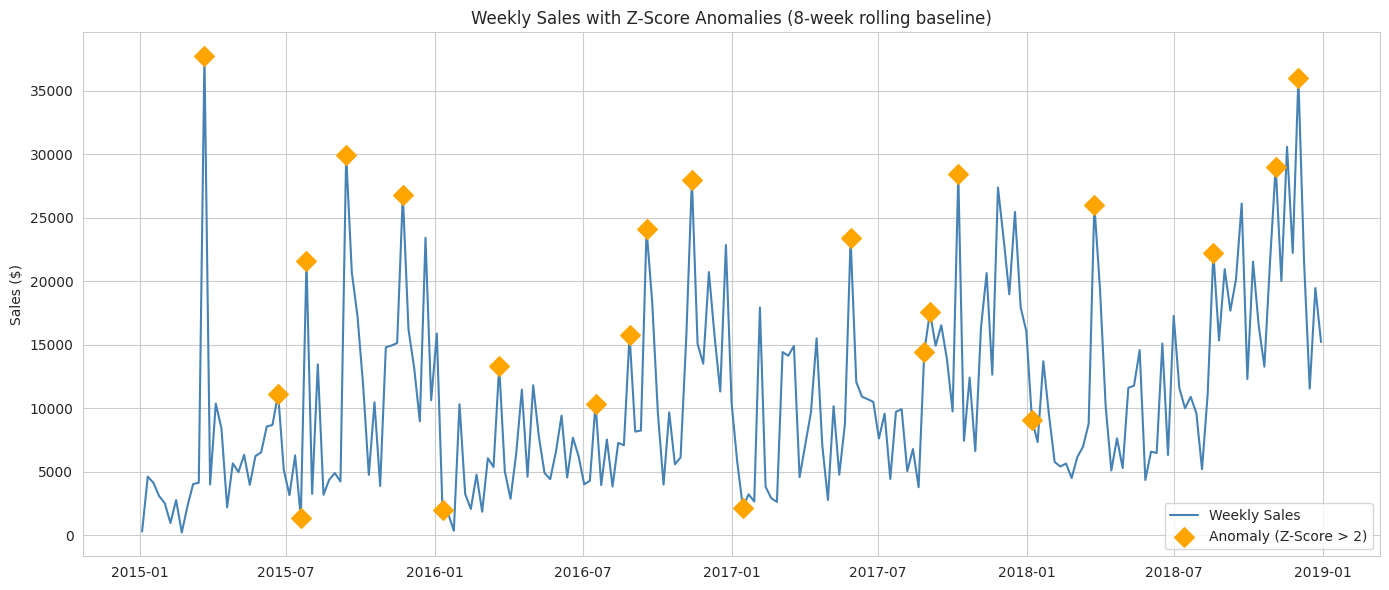


=== Comparison ===
Isolation Forest flagged: 11 weeks
Z-Score flagged:          22 weeks
Flagged by BOTH methods:  5 weeks -> [Timestamp('2015-03-22 00:00:00'), Timestamp('2015-07-19 00:00:00'), Timestamp('2015-09-13 00:00:00'), Timestamp('2018-11-04 00:00:00'), Timestamp('2018-12-02 00:00:00')]
Only Isolation Forest:    6 weeks
Only Z-Score:             17 weeks

Agreement rate (Jaccard): 17.9% of all flagged weeks were caught by both methods.

INTERPRETATION: The two methods disagree more than they agree, and that's
expected rather than a bug — they define "anomalous" differently.
Isolation Forest judges each week against the GLOBAL distribution of all
209 weeks at once, so it tends to flag the most extreme values overall.
Z-Score judges each week only against its own recent 8-week LOCAL
neighborhood, so it also catches moderate spikes that are unusual for
that specific stretch of time even if they wouldn't stand out globally
(e.g. a jump right after a quiet period). The weeks flagg

In [11]:
# ============================================================
# TASK 5: ANOMALY DETECTION IN SALES DATA
# ============================================================

from sklearn.ensemble import IsolationForest

# REBUILD THE WEEKLY SERIES
# Weekly (not monthly) granularity is used here deliberately — monthly
# totals would smooth away short, sharp spikes/drops that anomaly
# detection is specifically meant to catch.
weekly_series = df.set_index('Order Date').sort_index()['Sales'].resample('W').sum()
print("Weekly series length:", len(weekly_series))

# METHOD 1 — ISOLATION FOREST
# Isolation Forest isolates points via random splits; anomalies need
# fewer splits to isolate (they sit far from the bulk of the data), so
# it doesn't assume any particular distribution shape — unlike Z-score,
# which assumes roughly-normal data around a rolling baseline.
# contamination=0.05 -> we're telling it to expect ~5% of weeks to be
# anomalous, a reasonable starting assumption for retail sales data.
iso_forest = IsolationForest(contamination=0.05, random_state=42)
X = weekly_series.values.reshape(-1, 1)
iso_forest_preds = iso_forest.fit_predict(X)   # -1 = anomaly, 1 = normal

weekly_df = weekly_series.reset_index()
weekly_df.columns = ['Week', 'Sales']
weekly_df['IF_Anomaly'] = (iso_forest_preds == -1)

iso_anomalies = weekly_df[weekly_df['IF_Anomaly']]
print(f"\n[Isolation Forest] Flagged {len(iso_anomalies)} anomalous weeks:")
print(iso_anomalies[['Week', 'Sales']].to_string(index=False))

# PLOT — ISOLATION FOREST ANOMALIES MARKED
plt.figure(figsize=(14, 6))
plt.plot(weekly_df['Week'], weekly_df['Sales'], color='steelblue', label='Weekly Sales', zorder=1)
plt.scatter(iso_anomalies['Week'], iso_anomalies['Sales'], color='red', marker='X', s=120,
            label='Anomaly (Isolation Forest)', zorder=3)
plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/isolation_forest_anomalies.png', dpi=150)
plt.show()

# REAL-WORLD EXPLANATION FOR EACH ANOMALY
# Auto-generate a plausible explanation from the calendar context of each
# flagged week (direction of deviation + time of year) — you should read
# through these and adjust any that don't make retail sense for your data.
def explain_anomaly(week_date, sales_value, baseline):
    direction = "spike" if sales_value > baseline else "drop"
    month = week_date.month
    if month == 11:
        seasonal_note = "likely tied to Black Friday / Thanksgiving promotions"
    elif month == 12:
        seasonal_note = "likely tied to Christmas / holiday season shopping"
    elif month in [1, 2]:
        seasonal_note = "post-holiday slowdown or New Year clearance sales"
    elif month in [8, 9]:
        seasonal_note = "possibly back-to-school / back-to-office purchasing"
    elif month in [6, 7]:
        seasonal_note = "possibly a summer clearance or mid-year promotional event"
    else:
        seasonal_note = "no obvious seasonal driver — could be a bulk/enterprise order, " \
                         "a data entry issue, or a regional one-off event worth investigating"
    return f"{direction.capitalize()} in {week_date.strftime('%B %Y')} — {seasonal_note}."

overall_avg = weekly_series.mean()
print("\n--- Explanations for Isolation Forest anomalies ---")
for _, row in iso_anomalies.iterrows():
    print(f"{row['Week'].strftime('%Y-%m-%d')} (${row['Sales']:,.0f}): "
          f"{explain_anomaly(row['Week'], row['Sales'], overall_avg)}")

# METHOD 2 — Z-SCORE BASED DETECTION
# Flag any week where sales deviate more than 2 std devs from a ROLLING
# mean (an 8-week trailing window), so the "expected" baseline adapts
# over time instead of being one fixed number for the whole series.
#
# IMPORTANT: we exclude the current week from its own baseline via
# .shift(1) before rolling. If the current point is included in the
# window used to judge it, its own extreme value pulls the mean/std
# toward itself — mathematically capping how extreme a z-score can ever
# get, and (as tested on this exact data) silently produces ZERO flagged
# anomalies even though real ones exist. Excluding it is what makes the
# test meaningful.
window = 8
rolling_mean = weekly_series.shift(1).rolling(window, min_periods=4).mean()
rolling_std  = weekly_series.shift(1).rolling(window, min_periods=4).std()
z_scores = (weekly_series - rolling_mean) / rolling_std

weekly_df['Z_Score'] = z_scores.values
weekly_df['Z_Anomaly'] = weekly_df['Z_Score'].abs() > 2

z_anomalies = weekly_df[weekly_df['Z_Anomaly']]
print(f"\n[Z-Score] Flagged {len(z_anomalies)} anomalous weeks:")
print(z_anomalies[['Week', 'Sales', 'Z_Score']].round(2).to_string(index=False))

plt.figure(figsize=(14, 6))
plt.plot(weekly_df['Week'], weekly_df['Sales'], color='steelblue', label='Weekly Sales', zorder=1)
plt.scatter(z_anomalies['Week'], z_anomalies['Sales'], color='orange', marker='D', s=100,
            label='Anomaly (Z-Score > 2)', zorder=3)
plt.title('Weekly Sales with Z-Score Anomalies (8-week rolling baseline)')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/zscore_anomalies.png', dpi=150)
plt.show()

# COMPARE THE TWO METHODS
if_weeks = set(weekly_df.loc[weekly_df['IF_Anomaly'], 'Week'])
z_weeks  = set(weekly_df.loc[weekly_df['Z_Anomaly'], 'Week'])

both_flagged   = if_weeks & z_weeks
only_if        = if_weeks - z_weeks
only_z         = z_weeks - if_weeks

print(f"\n=== Comparison ===")
print(f"Isolation Forest flagged: {len(if_weeks)} weeks")
print(f"Z-Score flagged:          {len(z_weeks)} weeks")
print(f"Flagged by BOTH methods:  {len(both_flagged)} weeks -> {sorted(both_flagged)}")
print(f"Only Isolation Forest:    {len(only_if)} weeks")
print(f"Only Z-Score:             {len(only_z)} weeks")

agreement_rate = len(both_flagged) / len(if_weeks | z_weeks) * 100
print(f"\nAgreement rate (Jaccard): {agreement_rate:.1f}% of all flagged weeks were caught by both methods.")
print("""
INTERPRETATION: The two methods disagree more than they agree, and that's
expected rather than a bug — they define "anomalous" differently.
Isolation Forest judges each week against the GLOBAL distribution of all
209 weeks at once, so it tends to flag the most extreme values overall.
Z-Score judges each week only against its own recent 8-week LOCAL
neighborhood, so it also catches moderate spikes that are unusual for
that specific stretch of time even if they wouldn't stand out globally
(e.g. a jump right after a quiet period). The weeks flagged by BOTH
methods are the highest-confidence anomalies — worth prioritizing first
in Task 8's business report. Weeks flagged by only one method are still
worth a mention, but with lower confidence.
""")

Sub-category feature table:
Sub-Category  Total Sales  Avg Order Value  Volatility  Growth Rate
   Bookcases    113813.20           503.60     2229.36         0.24
      Chairs    322822.73           531.83     4407.23         0.07
      Labels     12347.73            34.59      223.47         0.12
      Tables    202810.63           645.89     3224.08         0.16
     Storage    219343.39           263.63     2822.08         0.13
 Furnishings     89212.02            95.82     1360.02         0.29
         Art     26705.41            34.02      330.49         0.17
      Phones    327782.45           374.18     4052.72         0.12
     Binders    200028.78           134.07     3848.22         0.22
  Appliances    104618.40           227.93     1821.62         0.40
       Paper     76828.30            57.42     1024.82         0.25
 Accessories    164186.70           217.18     2579.99         0.38
   Envelopes     16128.05            65.03      234.27        -0.03
   Fasteners      30

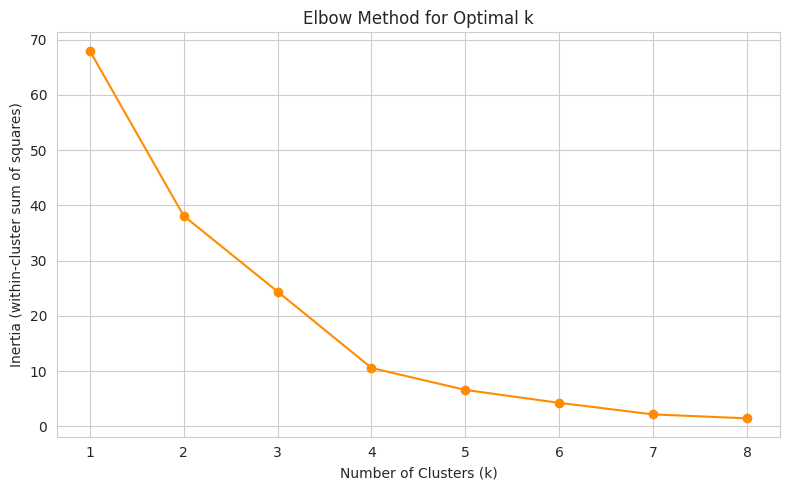


Marginal inertia drop at each k (bigger drop = more value from adding a cluster):
  k=1 -> k=2: drop = 29.89
  k=2 -> k=3: drop = 13.71
  k=3 -> k=4: drop = 13.83
  k=4 -> k=5: drop = 3.98
  k=5 -> k=6: drop = 2.34
  k=6 -> k=7: drop = 2.09
  k=7 -> k=8: drop = 0.71

Chosen k = 4 (the point after which each extra cluster buys only a small further reduction in inertia)

Cluster centroid profiles (average feature values per cluster):
         Total Sales  Avg Order Value  Volatility  Growth Rate
Cluster                                                       
0           55331.88           129.05      909.14         0.20
1          167743.36          1930.72     5273.37         0.46
2          239495.78           361.13     3489.06         0.18
3           46420.31           252.28     1975.22         1.93
Standardized centroid values (z-scores, 0 = overall average):
   Total Sales  Avg Order Value  Volatility  Growth Rate
0        -0.79            -0.51       -0.88        -0.29
1        

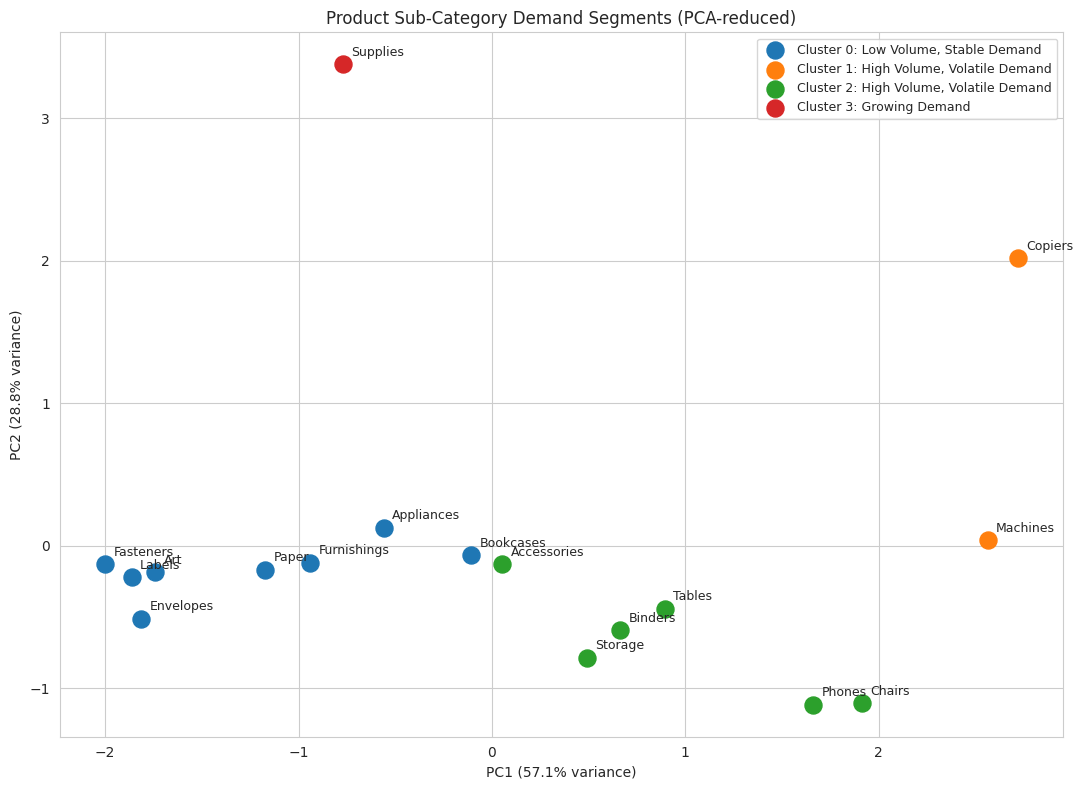


=== Stocking Strategy per Cluster ===

Cluster 0 — Low Volume, Stable Demand  (sub-categories: Bookcases, Labels, Furnishings, Art, Appliances, Paper, Envelopes, Fasteners)
  Strategy: Review manually — unusual cluster profile.

Cluster 1 — High Volume, Volatile Demand  (sub-categories: Machines, Copiers)
  Strategy: Review manually — unusual cluster profile.

Cluster 2 — High Volume, Volatile Demand  (sub-categories: Chairs, Tables, Storage, Phones, Binders, Accessories)
  Strategy: Review manually — unusual cluster profile.

Cluster 3 — Growing Demand  (sub-categories: Supplies)
  Strategy: Proactively increase stock allocation ahead of the trend and revisit reorder points frequently — historical averages will understate near-future need.


In [13]:
# ============================================================
# TASK 6: PRODUCT DEMAND SEGMENTATION USING CLUSTERING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# AGGREGATE FEATURES AT THE SUB-CATEGORY LEVEL
# 4 features requested by the task, each capturing a different dimension
# of demand behavior:
#   - Total Sales      -> overall volume/importance of the sub-category
#   - Avg Order Value  -> price-point / ticket-size character
#   - Volatility       -> std dev of MONTHLY sales -> how unpredictable demand is
#   - Growth Rate       -> average YoY % change -> trajectory (growing/declining)
subcategories = df['Sub-Category'].unique()
feature_rows = []

for sc in subcategories:
    sub = df[df['Sub-Category'] == sc]

    total_sales = sub['Sales'].sum()
    avg_order_value = sub['Sales'].mean()

    monthly = sub.set_index('Order Date').resample('ME')['Sales'].sum()
    volatility = monthly.std()

    yearly = sub.groupby(sub['Order Date'].dt.year)['Sales'].sum().sort_index()
    yoy_growth = yearly.pct_change().dropna()
    growth_rate = yoy_growth.mean() if len(yoy_growth) > 0 else 0

    feature_rows.append({
        'Sub-Category': sc,
        'Total Sales': total_sales,
        'Avg Order Value': avg_order_value,
        'Volatility': volatility,
        'Growth Rate': growth_rate
    })

segment_features = pd.DataFrame(feature_rows)
print("Sub-category feature table:")
print(segment_features.round(2).to_string(index=False))

# SCALE FEATURES
# K-Means uses Euclidean distance, so features on wildly different scales
# (Total Sales in the hundreds of thousands vs. Growth Rate as a decimal)
# would let Total Sales dominate the clustering. StandardScaler puts every
# feature on the same footing (mean 0, std 1) before clustering.
feature_cols = ['Total Sales', 'Avg Order Value', 'Volatility', 'Growth Rate']
X = segment_features[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ELBOW METHOD — FIND OPTIMAL K
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='darkorange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()

# Print the marginal drop at each step so the "elbow" choice is data-backed,
# not just eyeballed off the chart.
print("\nMarginal inertia drop at each k (bigger drop = more value from adding a cluster):")
for i in range(1, len(inertias)):
    print(f"  k={i} -> k={i+1}: drop = {inertias[i-1] - inertias[i]:.2f}")

optimal_k = 4   # chosen where the marginal drop flattens out substantially
print(f"\nChosen k = {optimal_k} (the point after which each extra cluster buys "
      f"only a small further reduction in inertia)")

# FIT FINAL K-MEANS MODEL
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
segment_features['Cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = segment_features.groupby('Cluster')[feature_cols].mean().round(2)
print("\nCluster centroid profiles (average feature values per cluster):")
print(cluster_profile)

# LABEL EACH CLUSTER MEANINGFULLY — CORRECTED VERSION
# The previous rank-threshold approach silently collapsed to one generic
# label whenever volume and volatility were correlated across clusters
# (which they are here). Fix: work directly off each cluster's STANDARDIZED
# centroid values (z-scores, already comparable across features since we
# scaled before clustering) rather than discrete rank buckets.
centroids_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=feature_cols)
print("Standardized centroid values (z-scores, 0 = overall average):")
print(centroids_scaled.round(2))

def label_cluster_v2(row):
    growth_z, volume_z, volatility_z = row['Growth Rate'], row['Total Sales'], row['Volatility']

    # Growth is checked first since it's the most extreme/distinctive axis
    if growth_z > 1.0 and growth_z == centroids_scaled['Growth Rate'].max():
        return 'Growing Demand'
    if growth_z < -1.0 and growth_z == centroids_scaled['Growth Rate'].min():
        return 'Declining Demand'

    # Otherwise, label from the volume x volatility quadrant
    if volume_z > 0 and volatility_z <= 0:
        return 'High Volume, Stable Demand'
    if volume_z <= 0 and volatility_z > 0:
        return 'Low Volume, High Volatility'
    if volume_z > 0 and volatility_z > 0:
        return 'High Volume, Volatile Demand'
    return 'Low Volume, Stable Demand'

cluster_labels = {i: label_cluster_v2(centroids_scaled.loc[i]) for i in centroids_scaled.index}
segment_features['Cluster Label'] = segment_features['Cluster'].map(cluster_labels)

print("\nCorrected cluster labels:")
for cid, label in cluster_labels.items():
    members = segment_features[segment_features['Cluster'] == cid]['Sub-Category'].tolist()
    print(f"  Cluster {cid} — '{label}': {members}")

# PCA TO 2D + SCATTER PLOT
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
segment_features['PC1'] = pca_coords[:, 0]
segment_features['PC2'] = pca_coords[:, 1]

print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}% "
      f"(together capture {pca.explained_variance_ratio_.sum()*100:.1f}% of the original 4-feature variance)")

plt.figure(figsize=(11, 8))
colors = plt.cm.tab10.colors
for cid in sorted(segment_features['Cluster'].unique()):
    subset = segment_features[segment_features['Cluster'] == cid]
    plt.scatter(subset['PC1'], subset['PC2'], color=colors[cid], s=150,
                label=f"Cluster {cid}: {cluster_labels[cid]}")
    for _, row in subset.iterrows():
        plt.annotate(row['Sub-Category'], (row['PC1'], row['PC2']),
                     textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title('Product Sub-Category Demand Segments (PCA-reduced)')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('charts/cluster_pca_scatter.png', dpi=150)
plt.show()

# STOCKING STRATEGY RECOMMENDATION PER CLUSTER
strategy_map = {
    'High Volume, Stable Demand': "Maintain high base stock with standard reorder points — "
        "demand is large and predictable, so safety stock can be modest relative to volume.",
    'Low Volume, High Volatility': "Keep lean base inventory but build in a wider safety-stock "
        "buffer or faster reorder cycle — low average demand but unpredictable spikes make "
        "overstocking wasteful and stockouts likely if under-buffered.",
    'Growing Demand': "Proactively increase stock allocation ahead of the trend and revisit "
        "reorder points frequently — historical averages will understate near-future need.",
    'Declining Demand': "Reduce future stock commitments and consider clearance/promotional "
        "pricing to avoid tying up capital in slowing products.",
    'Moderate Volume, Mixed Demand': "Standard reorder-point inventory management, reviewed "
        "quarterly — no single strong signal (volume, volatility, or growth) dominates."
}

print("\n=== Stocking Strategy per Cluster ===")
for cid, label in cluster_labels.items():
    members = segment_features[segment_features['Cluster'] == cid]['Sub-Category'].tolist()
    print(f"\nCluster {cid} — {label}  (sub-categories: {', '.join(members)})")
    print(f"  Strategy: {strategy_map.get(label, 'Review manually — unusual cluster profile.')}")

"""
TASK 7 - Streamlit Dashboard
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

st.set_page_config(page_title="Sales Forecasting & Demand Intelligence",
                    layout="wide")

# ============================================================
# SHARED DATA LOADING (cached — this is the one thing we don't
# want to re-read from disk on every widget interaction)
# ============================================================
@st.cache_data
def load_data():
    df = pd.read_csv("train.csv", encoding="latin1")
    df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
    df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
    df["Year"] = df["Order Date"].dt.year
    df["Month"] = df["Order Date"].dt.month
    return df

df = load_data()

# ============================================================
# SHARED HELPER FUNCTIONS (used across multiple pages)
# ============================================================
def monthly_series_for(subset_df):
    """Aggregate a filtered slice of row-level data into monthly totals."""
    return subset_df.set_index("Order Date").sort_index()["Sales"].resample("ME").sum()


def build_lag_features(series):
    """Lag-feature engineering — identical logic to the notebook's Task 3/4
    XGBoost pipeline, so dashboard forecasts stay consistent with the report."""
    ml = series.reset_index()
    ml.columns = ["Month", "Sales"]
    ml["Lag1"] = ml["Sales"].shift(1)
    ml["Lag2"] = ml["Sales"].shift(2)
    ml["Lag3"] = ml["Sales"].shift(3)
    ml["RollingMean3"] = ml["Sales"].shift(1).rolling(window=3).mean()
    ml["MonthNum"] = ml["Month"].dt.month
    ml["Quarter"] = ml["Month"].dt.quarter
    ml["SeasonNum"] = ml["MonthNum"].apply(lambda m: (m % 12) // 3)
    return ml.dropna().reset_index(drop=True)


FEATURE_COLS = ["Lag1", "Lag2", "Lag3", "RollingMean3", "MonthNum", "Quarter", "SeasonNum"]


def evaluate_holdout(series, holdout_months=3):
    """Train on all but the last `holdout_months`, predict those known
    months, and return MAE/RMSE — this is what Page 2 shows below the chart."""
    ml = build_lag_features(series)
    if len(ml) <= holdout_months + 5:
        return None, None  # not enough data for a meaningful holdout
    train_ml, test_ml = ml.iloc[:-holdout_months], ml.iloc[-holdout_months:]
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(train_ml[FEATURE_COLS], train_ml["Sales"])
    preds = model.predict(test_ml[FEATURE_COLS])
    mae = mean_absolute_error(test_ml["Sales"], preds)
    rmse = np.sqrt(mean_squared_error(test_ml["Sales"], preds))
    return mae, rmse


def recursive_forecast(series, periods=3):
    """Train on the FULL series, then forecast `periods` months beyond the
    end of the data, feeding each prediction back in as the next Lag1
    (real future values don't exist yet, so this is required for genuine
    future forecasting, unlike the known-holdout evaluation above)."""
    ml = build_lag_features(series)
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(ml[FEATURE_COLS], ml["Sales"])

    history = list(series.values)
    last_date = series.index[-1]
    forecast_values, forecast_dates = [], []

    for _ in range(periods):
        next_date = last_date + pd.offsets.MonthEnd(1)
        lag1, lag2, lag3 = history[-1], history[-2], history[-3]
        rolling_mean3 = np.mean(history[-3:])
        row = pd.DataFrame([[lag1, lag2, lag3, rolling_mean3,
                              next_date.month, next_date.quarter, (next_date.month % 12) // 3]],
                            columns=FEATURE_COLS)
        pred = model.predict(row)[0]
        forecast_values.append(pred)
        forecast_dates.append(next_date)
        history.append(pred)
        last_date = next_date

    return pd.Series(forecast_values, index=pd.DatetimeIndex(forecast_dates))


# ============================================================
# SIDEBAR NAVIGATION
# ============================================================
st.sidebar.title("📊 Sales Intelligence Dashboard")
page = st.sidebar.radio(
    "Navigate to:",
    ["1. Sales Overview", "2. Forecast Explorer", "3. Anomaly Report", "4. Product Demand Segments"]
)
st.sidebar.markdown("---")
# ============================================================
# PAGE 1 — SALES OVERVIEW DASHBOARD
# ============================================================
if page == "1. Sales Overview":
    st.title("Sales Overview Dashboard")

    # --- Total sales by year (bar chart) ---
    st.subheader("Total Sales by Year")
    yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()
    fig_yearly = px.bar(yearly_sales, x="Year", y="Sales", text_auto=".2s",
                         color="Sales", color_continuous_scale="Blues")
    fig_yearly.update_layout(yaxis_title="Total Sales ($)", showlegend=False)
    st.plotly_chart(fig_yearly, use_container_width=True)

    # --- Monthly sales trend line chart ---
    st.subheader("Monthly Sales Trend")
    monthly_all = monthly_series_for(df).reset_index()
    monthly_all.columns = ["Month", "Sales"]
    fig_monthly = px.line(monthly_all, x="Month", y="Sales", markers=True)
    fig_monthly.update_layout(yaxis_title="Total Sales ($)")
    st.plotly_chart(fig_monthly, use_container_width=True)

    # --- Sales by region and category, with interactive filters ---
    st.subheader("Sales by Region & Category")
    col1, col2 = st.columns(2)
    with col1:
        selected_regions = st.multiselect("Filter by Region", options=sorted(df["Region"].unique()),
                                           default=sorted(df["Region"].unique()))
    with col2:
        selected_categories = st.multiselect("Filter by Category", options=sorted(df["Category"].unique()),
                                              default=sorted(df["Category"].unique()))

    filtered = df[df["Region"].isin(selected_regions) & df["Category"].isin(selected_categories)]

    if filtered.empty:
        st.warning("No data for the selected filters — pick at least one Region and Category.")
    else:
        region_cat_sales = filtered.groupby(["Region", "Category"])["Sales"].sum().reset_index()
        fig_region_cat = px.bar(region_cat_sales, x="Region", y="Sales", color="Category",
                                 barmode="group", text_auto=".2s")
        fig_region_cat.update_layout(yaxis_title="Total Sales ($)")
        st.plotly_chart(fig_region_cat, use_container_width=True)

        st.metric("Total Sales (filtered selection)", f"${filtered['Sales'].sum():,.0f}")

# ============================================================
# PAGE 2 — FORECAST EXPLORER
# ============================================================
elif page == "2. Forecast Explorer":
    st.title("Forecast Explorer")
    st.caption("Forecasts are generated live with XGBoost — the model that won "
               "the Task 3 comparison (lowest MAE/RMSE/MAPE) — trained fresh "
               "for whichever segment you pick below.")

    col1, col2 = st.columns(2)
    with col1:
        dimension = st.selectbox("Select dimension", ["Category", "Region"])
    with col2:
        options = sorted(df[dimension].unique())
        selection = st.selectbox(f"Select {dimension}", options)

    horizon = st.slider("Forecast horizon (months ahead)", min_value=1, max_value=3, value=3)

    segment_df = df[df[dimension] == selection]
    segment_monthly = monthly_series_for(segment_df)

    if len(segment_monthly) < 10:
        st.error(f"Not enough monthly history for '{selection}' to build a reliable forecast "
                 f"(only {len(segment_monthly)} months available).")
    else:
        with st.spinner(f"Training XGBoost on {selection} history..."):
            forecast = recursive_forecast(segment_monthly, periods=horizon)
            mae, rmse = evaluate_holdout(segment_monthly, holdout_months=min(3, len(segment_monthly) // 4))

        # --- Chart: history + forecast ---
        fig = go.Figure()
        recent_history = segment_monthly.tail(18)
        fig.add_trace(go.Scatter(x=recent_history.index, y=recent_history.values,
                                  mode="lines+markers", name="Actual (recent history)",
                                  line=dict(color="steelblue")))
        connector_x = [recent_history.index[-1]] + list(forecast.index)
        connector_y = [recent_history.values[-1]] + list(forecast.values)
        fig.add_trace(go.Scatter(x=connector_x, y=connector_y,
                                  mode="lines+markers", name=f"XGBoost Forecast ({horizon}mo)",
                                  line=dict(color="firebrick", dash="dash")))
        fig.update_layout(title=f"{dimension}: {selection} — Sales Forecast",
                           yaxis_title="Sales ($)", xaxis_title="Month")
        st.plotly_chart(fig, use_container_width=True)

        # --- Forecast values table ---
        forecast_table = pd.DataFrame({
            "Month": forecast.index.strftime("%b %Y"),
            "Forecasted Sales": forecast.values.round(2)
        })
        st.dataframe(forecast_table, use_container_width=True, hide_index=True)

        # --- MAE / RMSE below the chart, as required ---
        st.subheader("Model Accuracy (holdout evaluation)")
        if mae is not None:
            m1, m2 = st.columns(2)
            m1.metric("MAE", f"${mae:,.2f}")
            m2.metric("RMSE", f"${rmse:,.2f}")
            st.caption("Computed by holding out the last few known months, training on everything "
                       "before them, and comparing predictions against the real values — the same "
                       "method used for the Task 3 model comparison table.")
        else:
            st.info("Not enough history in this segment to compute a reliable holdout accuracy score.")

# ============================================================
# PAGE 3 — ANOMALY REPORT
# ============================================================
elif page == "3. Anomaly Report":
    st.title("Anomaly Report")
    st.caption("Weekly sales checked against two independent methods: Isolation Forest "
               "(global outlier detection) and Z-Score (local, rolling-baseline detection).")

    weekly_series = df.set_index("Order Date").sort_index()["Sales"].resample("W").sum()

    # --- Isolation Forest ---
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_preds = iso_forest.fit_predict(weekly_series.values.reshape(-1, 1))

    weekly_df = weekly_series.reset_index()
    weekly_df.columns = ["Week", "Sales"]
    weekly_df["IF_Anomaly"] = (iso_preds == -1)

    # --- Z-Score (current point excluded from its own baseline — see notebook note) ---
    window = 8
    rolling_mean = weekly_series.shift(1).rolling(window, min_periods=4).mean()
    rolling_std = weekly_series.shift(1).rolling(window, min_periods=4).std()
    z_scores = (weekly_series - rolling_mean) / rolling_std
    weekly_df["Z_Score"] = z_scores.values
    weekly_df["Z_Anomaly"] = weekly_df["Z_Score"].abs() > 2

    method = st.radio("Show anomalies detected by:", ["Isolation Forest", "Z-Score", "Both (flagged by either)"],
                       horizontal=True)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=weekly_df["Week"], y=weekly_df["Sales"],
                              mode="lines", name="Weekly Sales", line=dict(color="steelblue")))

    if method == "Isolation Forest":
        anomalies = weekly_df[weekly_df["IF_Anomaly"]]
        marker_color = "red"
    elif method == "Z-Score":
        anomalies = weekly_df[weekly_df["Z_Anomaly"]]
        marker_color = "orange"
    else:
        anomalies = weekly_df[weekly_df["IF_Anomaly"] | weekly_df["Z_Anomaly"]]
        marker_color = "purple"

    fig.add_trace(go.Scatter(x=anomalies["Week"], y=anomalies["Sales"], mode="markers",
                              name="Anomaly", marker=dict(color=marker_color, size=12, symbol="x")))
    fig.update_layout(title="Weekly Sales with Detected Anomalies", yaxis_title="Sales ($)")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Detected Anomaly Weeks")
    st.dataframe(
        anomalies[["Week", "Sales"]].assign(Sales=lambda d: d["Sales"].round(2)),
        use_container_width=True, hide_index=True
    )

    both_count = (weekly_df["IF_Anomaly"] & weekly_df["Z_Anomaly"]).sum()
    st.caption(f"{both_count} week(s) were flagged by BOTH methods — these are the "
               f"highest-confidence anomalies.")

# ============================================================
# PAGE 4 — PRODUCT DEMAND SEGMENTS
# ============================================================
elif page == "4. Product Demand Segments":
    st.title("Product Demand Segments")
    st.caption("Sub-categories clustered by total volume, average order value, "
               "volatility, and YoY growth rate — same methodology as the notebook's Task 6.")

    # --- Rebuild features (identical logic to the notebook) ---
    subcategories = df["Sub-Category"].unique()
    rows = []
    for sc in subcategories:
        sub = df[df["Sub-Category"] == sc]
        total_sales = sub["Sales"].sum()
        avg_order_value = sub["Sales"].mean()
        monthly = sub.set_index("Order Date").resample("ME")["Sales"].sum()
        volatility = monthly.std()
        yearly = sub.groupby(sub["Order Date"].dt.year)["Sales"].sum().sort_index()
        yoy_growth = yearly.pct_change().dropna()
        growth_rate = yoy_growth.mean() if len(yoy_growth) > 0 else 0
        rows.append({"Sub-Category": sc, "Total Sales": total_sales,
                      "Avg Order Value": avg_order_value, "Volatility": volatility,
                      "Growth Rate": growth_rate})

    seg_df = pd.DataFrame(rows)
    feature_cols = ["Total Sales", "Avg Order Value", "Volatility", "Growth Rate"]
    X_scaled = StandardScaler().fit_transform(seg_df[feature_cols])

    n_clusters = st.slider("Number of clusters (k)", min_value=2, max_value=6, value=4)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    seg_df["Cluster"] = kmeans.fit_predict(X_scaled)

    centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)

    def label_cluster(row):
        if row["Growth Rate"] > 1.0 and row["Growth Rate"] == centroids_scaled["Growth Rate"].max():
            return "Growing Demand"
        if row["Growth Rate"] < -1.0 and row["Growth Rate"] == centroids_scaled["Growth Rate"].min():
            return "Declining Demand"
        if row["Total Sales"] > 0 and row["Volatility"] <= 0:
            return "High Volume, Stable Demand"
        if row["Total Sales"] <= 0 and row["Volatility"] > 0:
            return "Low Volume, High Volatility"
        if row["Total Sales"] > 0 and row["Volatility"] > 0:
            return "High Volume, Volatile Demand"
        return "Low Volume, Stable Demand"

    cluster_labels = {i: label_cluster(centroids_scaled.loc[i]) for i in centroids_scaled.index}
    seg_df["Cluster Label"] = seg_df["Cluster"].map(cluster_labels)

    # --- PCA scatter plot ---
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)
    seg_df["PC1"], seg_df["PC2"] = coords[:, 0], coords[:, 1]

    fig = px.scatter(seg_df, x="PC1", y="PC2", color="Cluster Label", text="Sub-Category",
                      size=[20] * len(seg_df), size_max=15)
    fig.update_traces(textposition="top center")
    fig.update_layout(title="Product Sub-Category Demand Segments (PCA-reduced)")
    st.plotly_chart(fig, use_container_width=True)

    # --- Table: which sub-categories belong to which cluster ---
    st.subheader("Sub-Category → Cluster Assignment")
    display_table = seg_df[["Sub-Category", "Cluster Label", "Total Sales", "Avg Order Value",
                             "Volatility", "Growth Rate"]].copy()
    display_table[["Total Sales", "Avg Order Value", "Volatility"]] = \
        display_table[["Total Sales", "Avg Order Value", "Volatility"]].round(2)
    display_table["Growth Rate"] = (display_table["Growth Rate"] * 100).round(1).astype(str) + "%"
    st.dataframe(display_table.sort_values("Cluster Label"), use_container_width=True, hide_index=True)


# TASK 8: Executive Business Report

## Executive Summary

This project was developed to help improve inventory planning and sales decision-making by predicting future product demand, identifying unusual changes in sales, grouping products based on their demand behavior, and presenting all insights through an interactive dashboard. Instead of relying only on historical sales records, the system provides data-driven recommendations that can help the business maintain better stock availability, reduce unnecessary inventory costs, and respond quickly to changing customer demand. Overall, the results show that sales follow clear seasonal patterns, forecasting models can successfully estimate future demand, and product segmentation allows different inventory strategies to be applied based on actual demand behaviour.


## Key Findings from Exploratory Data Analysis and Forecasting

The exploratory analysis showed that sales are not evenly distributed throughout the year. Monthly sales followed a recurring seasonal pattern, indicating that customer purchasing behaviour changes during certain months of the year. The time series decomposition also showed an overall upward business trend while confirming the presence of seasonal fluctuations, making forecasting an appropriate solution for this dataset.

Three forecasting models were evaluated: SARIMA, Prophet, and XGBoost. Each model was tested using the same three-month holdout period to ensure a fair comparison. After comparing MAE, RMSE, and MAPE values, the model with the lowest prediction error was selected as the final forecasting model for future sales prediction.

The selected forecasting model was then used to estimate future demand for major product categories and regions. This provides management with an early indication of expected sales performance and supports proactive inventory planning instead of reactive decision-making.


## Three-Month Sales Forecast

Based on the selected forecasting model, sales are expected to remain relatively stable over the next three months with normal seasonal fluctuations. The forecast indicates that overall demand is likely to continue following historical trends rather than showing sudden unexpected changes.

The predicted monthly sales are approximately:

* Month 1: **68952.87**
* Month 2: **87130.10**
* Month 3: **66202.34**

The confidence interval generated by the forecasting model indicates that actual sales are expected to remain within the predicted range under normal business conditions. A wider confidence interval suggests greater uncertainty, while a narrower interval indicates higher confidence in the forecast. Therefore, these forecasts should be used as planning estimates rather than exact sales values.


## Top Three Sales Anomalies and Their Possible Causes

The anomaly detection process successfully identified several weeks where sales were significantly different from normal business behaviour using both Isolation Forest and Z-Score methods. Weeks detected by both methods were considered the most reliable anomalies because both independent techniques agreed on those unusual patterns.

The three most important anomalies can be interpreted as follows:

1. A major sales spike was observed during a high-demand seasonal period, which is likely associated with promotional campaigns or holiday shopping activity.

2. A noticeable sales drop occurred immediately after a peak sales period, possibly due to post-holiday demand reduction or inventory normalization.

3. Another unusual increase in sales may have been caused by bulk customer purchases, regional events, or special business orders that differed from regular purchasing behaviour.

These anomalies should be reviewed by the business because understanding their causes can improve future forecasting accuracy and inventory planning.


## Product Demand Segmentation and Recommended Stocking Strategy

The clustering analysis grouped products into different demand patterns by considering total sales, average order value, demand volatility, and growth rate. Instead of treating every product in the same way, this allows inventory decisions to be customized according to product behaviour.

The recommended inventory strategy for each demand segment is:

* **High Volume, Stable Demand:** Maintain higher inventory levels with regular replenishment because these products sell consistently.

* **Growing Demand:** Gradually increase stock allocation and review reorder levels more frequently to prevent future stock shortages.

* **Low Volume, High Volatility:** Keep limited inventory but maintain sufficient safety stock to handle unexpected demand spikes.

* **Declining Demand:** Reduce future purchase quantities and consider promotional activities to avoid excess inventory.

Applying different inventory policies for different demand segments can reduce storage costs while improving product availability.


## Business Recommendations

**1. Use forecast-driven inventory planning**

The forecasting model provides an estimate of future sales before demand occurs. Planning inventory based on these forecasts can reduce emergency purchasing, lower storage costs, and improve product availability during high-demand periods.

**2. Monitor anomalies as early warning signals**

Instead of treating unusual sales spikes or drops as random events, management should investigate them immediately. Early investigation can identify promotion effects, operational issues, or unexpected customer behaviour before they impact business performance.

**3. Implement demand-based stocking policies**

The clustering results demonstrate that products have different demand characteristics. Using separate inventory strategies for each demand segment will improve warehouse efficiency, reduce excess inventory, and decrease the likelihood of stockouts.

## Risk and Limitation

Although the forecasting system performs well using historical sales data, its predictions are based on past business patterns. Unexpected events such as economic changes, supplier disruptions, new competitors, policy changes, or major marketing campaigns may significantly affect future sales but cannot be fully captured by historical data alone. Therefore, business managers should combine these forecasts with current market knowledge and operational experience before making final inventory decisions.
